# Viscous Burgers equation in conservative form

In [ ]:
# %%
import numpy as np
import sympy as sp
from sympy.utilities.lambdify import lambdify
import matplotlib.pyplot as plt

# %%
# --- Symbolic analytical solution (Cole–Hopf) ---
x_sym, nu_sym, t_sym = sp.symbols('x nu t')

phi = (sp.exp(-(x_sym - 4 * t_sym)**2 / (4 * nu_sym * (t_sym + 1))) +
       sp.exp(-(x_sym - 4 * t_sym - 2 * sp.pi)**2 / (4 * nu_sym * (t_sym + 1))))

phiprime = phi.diff(x_sym)
u_expr = -2 * nu_sym * (phiprime / phi) + 4

ufunc = lambdify((t_sym, x_sym, nu_sym), u_expr)

# %%
# --- Grid setup ---
nx = 101
nt = 50
L = 2 * np.pi

dx = L / (nx - 1)
nu_val = 0.07

x = np.linspace(0, L, nx)

# %%
# --- Initial condition from analytical solution ---
t0 = 0.0
u = np.array([ufunc(t0, xi, nu_val) for xi in x])

# %%
# --- Time step (CFL safe) ---
dt = min(0.2 * dx / np.max(np.abs(u)),
         0.2 * dx**2 / nu_val)

print(f"dt = {dt:.5f}")

# %%
# --- Time marching (Rusanov flux + diffusion) ---
for n in range(nt):
    un = u.copy()

    # Conservative flux f = u^2 / 2
    f = 0.5 * un**2

    # Rusanov (local LF) flux at interfaces
    alpha = np.max(np.abs(un))

    flux = 0.5 * (f[1:] + f[:-1]) - 0.5 * alpha * (un[1:] - un[:-1])

    # Update interior points
    u[1:-1] = un[1:-1] \
        - dt/dx * (flux[1:] - flux[:-1]) \
        + nu_val * dt/dx**2 * (un[2:] - 2*un[1:-1] + un[:-2])

    # Periodic BC
    # left boundary
    f0 = 0.5 * un[0]**2
    fL = 0.5 * un[-2]**2

    flux_left = 0.5 * (f0 + fL) - 0.5 * alpha * (un[0] - un[-2])
    flux_right = flux[0]

    u[0] = un[0] \
        - dt/dx * (flux_right - flux_left) \
        + nu_val * dt/dx**2 * (un[1] - 2*un[0] + un[-2])

    u[-1] = u[0]  # periodic closure

# %%
# --- Analytical solution at final time ---
t_final = nt * dt
u_analytical = np.array([ufunc(t_final, xi, nu_val) for xi in x])

# %%
# --- Plot ---
plt.figure(figsize=(11, 7), dpi=100)
plt.plot(x, u, 'o-', lw=2, label='Rusanov (Conservative)')
plt.plot(x, u_analytical, '--', lw=2, label='Analytical')
plt.xlim([0, L])
plt.ylim([0, 10])
plt.xlabel('x')
plt.ylabel('u')
plt.title('Burgers Equation: Conservative vs Analytical')
plt.legend()
plt.grid()

plt.show()

# Viscous Burgers equation in non-conservative form with LF kind of viscosity for correct shock speed

dt = 0.00180


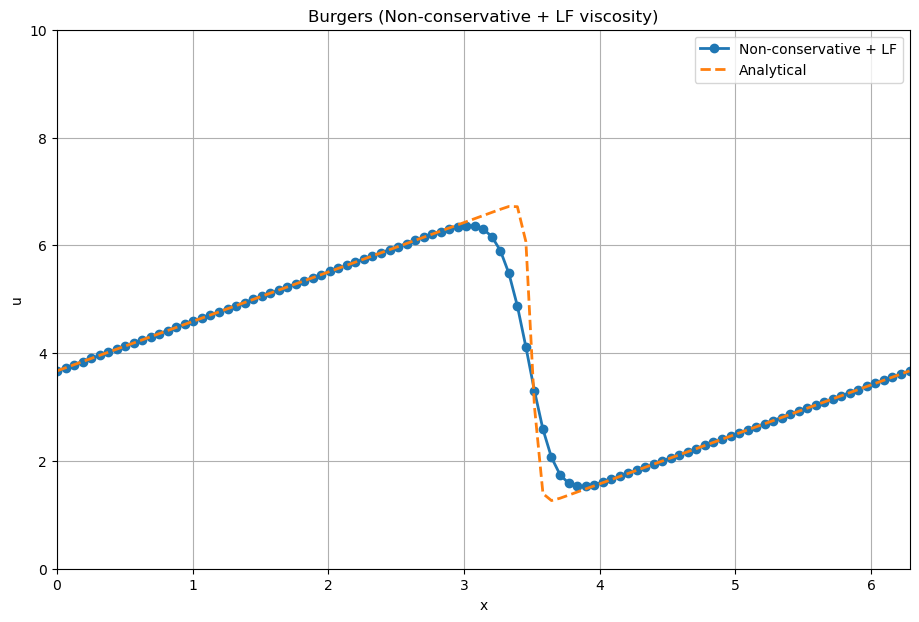

In [1]:
# %%
import numpy as np
import sympy as sp
from sympy.utilities.lambdify import lambdify
import matplotlib.pyplot as plt

# %%
# --- Analytical solution (Cole–Hopf) ---
x_sym, nu_sym, t_sym = sp.symbols('x nu t')

phi = (sp.exp(-(x_sym - 4 * t_sym)**2 / (4 * nu_sym * (t_sym + 1))) +
       sp.exp(-(x_sym - 4 * t_sym - 2 * sp.pi)**2 / (4 * nu_sym * (t_sym + 1))))

phiprime = phi.diff(x_sym)
u_expr = -2 * nu_sym * (phiprime / phi) + 4

ufunc = lambdify((t_sym, x_sym, nu_sym), u_expr)

# %%
# --- Grid ---
nx = 101
nt = 50
L = 2 * np.pi

dx = L / (nx - 1)
nu_val = 0.07

x = np.linspace(0, L, nx)

# %%
# --- Initial condition ---
t0 = 0.0
u = np.array([ufunc(t0, xi, nu_val) for xi in x])

# %%
# --- CFL-safe time step ---
dt = min(0.2 * dx / np.max(np.abs(u)),
         0.2 * dx**2 / nu_val)

print(f"dt = {dt:.5f}")

# %%
# --- Time marching (Non-conservative + LF viscosity) ---
for n in range(nt):
    un = u.copy()

    # LF wave speed
    alpha = np.max(np.abs(un))

    # Interior update
    u[1:-1] = un[1:-1] \
        - un[1:-1] * dt/dx * (un[1:-1] - un[:-2]) \
        + nu_val * dt/dx**2 * (un[2:] - 2*un[1:-1] + un[:-2]) \
        + (alpha * dt / (2*dx)) * (un[2:] - 2*un[1:-1] + un[:-2])

    # Periodic BC (left boundary)
    u[0] = un[0] \
        - un[0] * dt/dx * (un[0] - un[-2]) \
        + nu_val * dt/dx**2 * (un[1] - 2*un[0] + un[-2]) \
        + (alpha * dt / (2*dx)) * (un[1] - 2*un[0] + un[-2])

    u[-1] = u[0]

# %%
# --- Analytical solution ---
t_final = nt * dt
u_analytical = np.array([ufunc(t_final, xi, nu_val) for xi in x])

# %%
# --- Plot ---
plt.figure(figsize=(11, 7), dpi=100)
plt.plot(x, u, 'o-', lw=2, label='Non-conservative + LF')
plt.plot(x, u_analytical, '--', lw=2, label='Analytical')
plt.xlim([0, L])
plt.ylim([0, 10])
plt.xlabel('x')
plt.ylabel('u')
plt.title('Burgers (Non-conservative + LF viscosity)')
plt.legend()
plt.grid()

plt.show()